# Install Triton and verify installation

In [1]:
# Select GPU T4 x 2 accelator and install triton
!pip install triton

In [2]:
# Verify installation
import torch
import triton
import triton.language as tl 

# Check if Triton can access the GPU
print(f"Triton version: {triton.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"GPU Name: {torch.cuda.get_device_name(0)}")

# Simple test: define a JIT kernel
@triton.jit
def dummy_kernel(x_ptr):
    return

print("Triton JIT check: Success")

Triton version: 3.5.0
GPU Available: True
GPU Name: Tesla T4
Triton JIT check: Success


In [3]:
# Set cache directory
import os
os.environ["TRITON_CACHE_DIR"] = "/kaggle/working/triton_cache"

# Set device
current_device_id = torch.cuda.current_device()
DEVICE = torch.device(f"cuda:{current_device_id}")

# Layer Normalization

$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$

$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2$$

$$\hat{x}_i = \frac{x_i - \mu}{\sqrt{\sigma^2 + \varepsilon}}$$

$$y_i = \gamma_i \hat{x}_i + \beta_i$$

**Concepts**
- Backward pass
- Connect backward pass to PyTorch's graph
- Re-use intermediate values from forward pass and backward pass
- Locks and atomic operations
- Two sequential kernels can be faster than a single kernel

### Kernel and Wrapper

In [4]:
@triton.jit
def _layer_norm_forward(
    # Pointers to input
    x_ptr, y_ptr, weight_ptr, bias_ptr, mean_ptr, rstd_ptr,
    # Stride
    stride_m,
    # Dimensions
    N,
    # Other
    epsilon,
    # Meta-parameters
    BLOCK_SIZE: tl.constexpr,
):
    ## Each program handles one row of the 2D input
    # Map program id to row of x and y
    row = tl.program_id(axis=0)
    x_ptr += row * stride_m # Move x_ptr to start of this program's row in x
    y_ptr += row * stride_m # # Move x_ptr to start of this program's row in y

    # Compute mean
    sum_accumulator = tl.zeros([BLOCK_SIZE], dtype=tl.float32)
    for offset in range(0, N, BLOCK_SIZE):
        cols = offset + tl.arange(0, BLOCK_SIZE)
        x = tl.load(x_ptr + cols, mask=cols < N, other=0.0).to(tl.float32) # i/p is FP16, rounding error builds up so cast to FP32 for stability and accuracy
        sum_accumulator += x

    mean = tl.sum(sum_accumulator, axis=0) / N

    # Compute variance and reciprocal standard deviation
    mul_sum_accumulator = tl.zeros([BLOCK_SIZE], dtype=tl.float32)
    for offset in range(0, N, BLOCK_SIZE):
        cols = offset + tl.arange(0, BLOCK_SIZE)
        x = tl.load(x_ptr + cols, mask=cols < N, other=0.0).to(tl.float32)
        # During loading out-of-bound values were set as 0.0 so mask again to remove those otherwise instead of 0 we will have 0.0 - mean 
        diff = tl.where(cols < N, x - mean, 0.0) 
        mul_sum_accumulator += diff * diff

    var = tl.sum(mul_sum_accumulator, axis=0) / N
    rstd = 1.0 / tl.sqrt(var + epsilon)

    # Store mean and rstd for backward pass
    tl.store(mean_ptr + row, value=mean)
    tl.store(rstd_ptr + row, value=rstd)

    # Normalize and apply transformation
    for offset in range(0, N, BLOCK_SIZE):
        cols = offset + tl.arange(0, BLOCK_SIZE)
        mask = cols < N
        w = tl.load(weight_ptr + cols, mask=mask, other=0.0)
        b = tl.load(bias_ptr + cols, mask=mask, other=0.0)
        x = tl.load(x_ptr + cols, mask=mask, other=0.0)

        # Normalize
        x_hat = (x - mean) * rstd

        # Apply transformation
        y = w * x_hat + b

        # Store output
        tl.store(y_ptr + cols, value=y, mask=mask)


# dLdx, dLdy, dLdw_inter, dLdb_inter, x, weight, bias, mean, rstd, lock,
@triton.jit
def _layer_norm_backward_dLdx(
    # Pointers
    dLdx_ptr, dLdy_ptr, dLdw_inter_ptr, dLdb_inter_ptr,
    x_ptr, w_ptr, mean_ptr, rstd_ptr, lock_ptr,
    stride_m,
    # Dimensions
    N, # Number of columns in x
    # Meta-parameters
    GROUP_SIZE_M:tl.constexpr,
    BLOCK_SIZE_N:tl.constexpr,
):
    ## Each program handles one row of the 2D input
    # Map program id to elements of x, dLdx, dLdy it should compute
    pid = tl.program_id(axis=0)
    cols = tl.arange(0, BLOCK_SIZE_N)
    mask = cols < N
    x_ptr += pid * stride_m
    dLdx_ptr += pid * stride_m
    dLdy_ptr += pid * stride_m

    # Find out lock id that corresponds to current program id. There are GROUP_SIZE_M
    # number of locks
    lock_id = pid % GROUP_SIZE_M
    lock_ptr += lock_id # locks[0 : GROUP_SIZE_M] -> Stores whether a groups lock is ON or OFF 
    count_ptr = lock_ptr + GROUP_SIZE_M # locks[GROUP_SIZE_M : 2 * GROUP_SIZE_M] -> Count number of accumulations already happened on current lock

    # Find out intermediate dLdw and dLdb pointers
    dLdw_inter_ptrs = dLdw_inter_ptr + lock_id * N + cols
    dLdb_inter_ptrs = dLdb_inter_ptr + lock_id * N + cols

    # Load data to SRAM
    x = tl.load(x_ptr + cols, mask=mask, other=0.0).to(tl.float32) # [BLOCK_SIZE_N]
    dLdy = tl.load(dLdy_ptr + cols, mask=mask, other=0.0).to(tl.float32) # [BLOCK_SIZE_N]
    w = tl.load(w_ptr + cols, mask=mask, other=0.0).to(tl.float32) # [BLOCK_SIZE_N]
    mean = tl.load(mean_ptr + pid).to(tl.float32) # [1]
    rstd = tl.load(rstd_ptr + pid).to(tl.float32) # [1]

    ## Compute dLdx
    x_hat = (x - mean) * rstd
    x_hat = tl.where(mask, x_hat, 0.0) # [BLOCK_SIZE_N]
    dydx_hat = dLdy * w 
    dydx_hat = tl.where(mask, dydx_hat, 0.0) # [BLOCK_SIZE_N]

    # Compute c1 = 1/n * <x_hat, dydx_hat> and c2 = 1/n * <1, dydx_hat>
    c1 = tl.sum(x_hat * dydx_hat, axis=0) / N # [1]
    c2 = tl.sum(dydx_hat, axis=0) / N # [1]

    dLdx = rstd * (dydx_hat - (x_hat * c1 + c2)) # [BLOCK_SIZE_N]
    tl.store(dLdx_ptr + cols, value=dLdx, mask=mask)

    # Accumulate partial sums for dLdw and dLd
    partial_dLdw = (dLdy * x_hat).to(w.dtype)
    partial_dLdb = (dLdy).to(w.dtype)

    # Performs an atomic compare-and-swap at the memory location specified by pointer. It compares 
    # content of a memory location w/ a given value, if they are same then modify the content of 
    # that memory location to a new given value. e.g. look at location that lock_ptr points to, if
    # it is 0 (unlocked) change it to 1 (locked) and return 0, and if it is locked (1) then leave it 
    # as it is and return 1
    while tl.atomic_cas(lock_ptr, cmp=0, val=1) == 1:
        pass

    count = tl.load(count_ptr) # [1]
    if count == 0:
        # If current program is the first one to access the lock it does not accumulate.
        # Performs an atomic exchange at the memory location specified by pointer. Here it sets 
        # the value at count_ptr as 1 so next program knows partial buffer has been initialized
        # So directly store the partial sums (see after else block)
        tl.atomic_xchg(count_ptr, val=1)
    else:
        # If the current program is not the first program in accumulation process then accumulate
        # partial sums
        partial_dLdw += tl.load(dLdw_inter_ptrs, mask=mask, other=0.0)
        partial_dLdb += tl.load(dLdb_inter_ptrs, mask=mask, other=0.0)
        
    # Store partial sums
    tl.store(dLdw_inter_ptrs, value=partial_dLdw, mask=mask)
    tl.store(dLdb_inter_ptrs, value=partial_dLdb, mask=mask)

    # Insert a barrier to synchronize all threads in a block before releasing the lock
    tl.debug_barrier()

    # Release the lock
    tl.atomic_xchg(lock_ptr, 0)


@triton.jit
def _layer_norm_backward_dLdw_dLdb(
    # Pointers
    dLdw_inter_ptr, # Pointer to partial sum of weights gradient
    dLdb_inter_ptr, # Pointer to partial sum of biases gradient
    dLdw_ptr, # Pointer to weights gradient
    dLdb_ptr, # Pointer to biases gradient
    # Dimensions
    M, # GROUP_SIZE_M
    N, # Number of columns
    # Meta-parameters
    BLOCK_SIZE_M:tl.constexpr,
    BLOCK_SIZE_N:tl.constexpr,
):
    ## Each program handles a block of size BLOCK_SIZE_N along N dimension
    pid = tl.program_id(axis=0)
    col_ptrs = pid * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)

    # Accumulators for dLdw and dLdb
    dLdw_accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    dLdb_accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)

    # Iterate through rows of dLdw_inter and dLdb_inter to sum them up
    for row_idx in range(0, M, BLOCK_SIZE_M):
        row_ptrs = row_idx + tl.arange(0, BLOCK_SIZE_M)
        mask = ((row_ptrs[:, None] < M) & (col_ptrs[None, :] < N))
        offsets = row_ptrs[:, None] * N + col_ptrs[None, :]

        # Load partial sums dLdw and dLdb and accumulate
        dLdw_partial = tl.load(dLdw_inter_ptr + offsets, mask=mask, other=0.0)
        dLdb_partial = tl.load(dLdb_inter_ptr + offsets, mask=mask, other=0.0)

        dLdw_accumulator += dLdw_partial
        dLdb_accumulator += dLdb_partial

    # Sum the accumulated dLdw and dLdb along M to get BLOCK_SIZE_N chunk of dLdw and dLdb
    # that was assigned to current program
    dLdw_sum = tl.sum(dLdw_accumulator, axis=0)
    dLdb_sum = tl.sum(dLdb_accumulator, axis=0)

    # Write the dLdw_sum and dLdb_sum to output weight gradient pointers
    tl.store(dLdw_ptr + col_ptrs, value=dLdw_sum, mask=col_ptrs < N)
    tl.store(dLdb_ptr + col_ptrs, value=dLdb_sum, mask=col_ptrs < N)


class LayerNorm(torch.autograd.Function):
    """
    Implement a custom forward and backward kernel
    """
    @staticmethod
    def forward(ctx, x, normalized_shape, weight, bias, epsilon):
        """
        ctx is used to save data needed later by backward
        """
        # Allocate output
        y = torch.empty_like(x)

        # Reshape input x into 2D tensor
        M, N = x.reshape(-1, x.shape[-1]).shape

        # Allocate intermediate results
        mean = torch.empty((M, ), dtype=torch.float32, device=x.device)
        rstd = torch.empty((M, ), dtype=torch.float32, device=x.device)

        ## Heuristics
        # Compute maximum number of elements that can fit in 64 KB
        MAX_FUSED_SIZE = 65536 // x.element_size() # 64 * 1024 bytes / bytes in an element of x
        BLOCK_SIZE = min(MAX_FUSED_SIZE, triton.next_power_of_2(N))
        if N > BLOCK_SIZE:
            raise RuntimeError(
                "This layer norm does not support feature dimension >= 64 KB."
            )
        # Heuristics for number of warps
        num_warps = min(max(BLOCK_SIZE // 256, 1), 8)

        # Enqueue kernel
        _layer_norm_forward[(M, )](
            x, y, weight, bias, 
            mean, rstd, # Intermediate results
            x.stride(0), 
            N, 
            epsilon,
            # Meta-parameters
            BLOCK_SIZE=BLOCK_SIZE, 
            num_warps=num_warps, 
        )

        # Save data needed later by backward pass
        ctx.save_for_backward(x, weight, bias, mean, rstd)
        ctx.BLOCK_SIZE = BLOCK_SIZE
        ctx.num_warps = num_warps
        ctx.epsilon = epsilon

        return y
        
    @staticmethod
    def backward(ctx, dLdy):
        """
        dLdy: Partial derivative of loss w.r.t. y
        """
        # Fetch the original inputs and intermediate results
        x, weight, bias, mean, rstd = ctx.saved_tensors
        
        # Reshape x into 2D tensor
        M, N = x.reshape(-1, x.shape[-1]).shape

        # Heuristics for amount of parallel reduction stream for dLdw and dLdb
        GROUP_SIZE_M = 64
        if N <= 8192: GROUP_SIZE_M = 96
        if N <= 4096: GROUP_SIZE_M = 128
        if N <= 1024: GROUP_SIZE_M = 256

        ## Allocate output
        dLdx = torch.empty_like(dLdy)
        dLdw = torch.empty((N, ), dtype=weight.dtype, device=weight.device)
        dLdb = torch.empty((N, ), dtype=bias.dtype, device=bias.device)
        # Intermediate output to compute dLdw and dLdb after first computing dLdx
        dLdw_inter = torch.empty((GROUP_SIZE_M, N), dtype=weight.dtype, device=weight.device)
        dLdb_inter = torch.empty((GROUP_SIZE_M, N), dtype=bias.dtype, device=bias.device)
        
        # Use a locks to prevent multiple programs from updating the same DRAM entries at the same time
        # locks[0 : GROUP_SIZE_M] -> Stores whether a groups lock is ON or OFF (i.e. held or available)
        # locks[GROUP_SIZE_M : 2 * GROUP_SIZE_M] -> Flags whether that groups partial buffer has already been initialized
        lock = torch.zeros(2 * GROUP_SIZE_M, dtype=torch.int32, device=weight.device)

        # Enqueue kernel using forward pass heuristics to compute dLdx and the partial sums for dLdw and dLdb
        _layer_norm_backward_dLdx[(M, )](
            dLdx, dLdy, dLdw_inter, dLdb_inter, x, weight, mean, rstd, lock,
            x.stride(0), N,
            BLOCK_SIZE_N=ctx.BLOCK_SIZE,
            GROUP_SIZE_M=GROUP_SIZE_M,
            num_warps=ctx.num_warps,
        )

        # Accumulate partial sums (dLdw_inter and dLdb_inter) into dLdw and dLdb in separate kernel
        grid = lambda meta: (triton.cdiv(N, meta["BLOCK_SIZE_N"]), )
        _layer_norm_backward_dLdw_dLdb[grid](
            dLdw_inter, dLdb_inter, dLdw, dLdb,
            min(GROUP_SIZE_M, M), N,
            BLOCK_SIZE_M=32,
            BLOCK_SIZE_N=128,
        )

        return dLdx, None, dLdw, dLdb, None


layer_norm = LayerNorm.apply

### Test and Benchmark Helpers

In [5]:
def test_layer_norm_kernel(M, N, dtype, epsilon=1e-5, atol=1e-2, rtol=0, device=DEVICE):
    torch.manual_seed(42)

    # Define inputs
    x = -2.3 + 0.5 * torch.randn((M, N), dtype=dtype, device=device)
    x.requires_grad_(True)
    weight = torch.rand((N, ), dtype=dtype, device=device, requires_grad=True)
    bias = torch.rand((N, ), dtype=dtype, device=device, requires_grad=True)

    # Forward pass
    y_triton = layer_norm(x, (N, ), weight, bias, epsilon)
    y_ref = torch.nn.functional.layer_norm(x, (N, ), weight, bias, epsilon).to(dtype)

    # Backward pass (triton)
    dLdy = 0.1 * torch.randn_like(x)
    y_triton.backward(dLdy, retain_graph=True) # Keep the autograd graph alive so backward pass can run again on same forward pass result
    dLdx_triton, dLdw_triton, dLdb_triton = [_.grad.clone() for _ in [x, weight, bias]] # Copy gradients
    x.grad, weight.grad, bias.grad = None, None, None # Reset gradients for next backward pass, i.e. prevent gradient accumulation
    
    # Backward pass (PyTorch)
    y_ref.backward(dLdy, retain_graph=True)
    dLdx_ref, dLdw_ref, dLdb_ref = [_.grad.clone() for _ in [x, weight, bias]]
    
    # Comparisons
    torch.testing.assert_close(y_triton, y_ref, atol=atol, rtol=rtol)
    print("Passed forward pass")
    torch.testing.assert_close(dLdx_triton, dLdx_ref, atol=atol, rtol=rtol)
    torch.testing.assert_close(dLdw_triton, dLdw_ref, atol=atol, rtol=rtol)
    torch.testing.assert_close(dLdb_triton, dLdb_ref, atol=atol, rtol=rtol)
    print("Passed backward pass")


@triton.testing.perf_report(
    triton.testing.Benchmark(
        x_names=["N"],
        x_vals=[512 * i for i in range(2, 32)],
        line_arg="provider",
        line_vals=["triton", "torch"],
        line_names=["Triton", "Torch"],
        styles=[("blue", "-"), ("red", "-")],
        ylabel="GB/s",
        plot_name="layer-norm-backward",
        args={"M": 4096, "dtype": torch.float16, "mode": "backward"}, # Benchmark backward pass
    )
)
def benchmark(M, N, dtype, provider, epsilon=1e-5, mode="backward", device=DEVICE):
    torch.manual_seed(42)
    # Create data
    x_shape = (M, N)
    w_shape = (x_shape[-1], )
    weight = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)
    bias = torch.rand(w_shape, dtype=dtype, device=device, requires_grad=True)

    x = -2.3 + 0.5 * torch.randn(x_shape, dtype=dtype, device=device)
    dy = .1 * torch.randn_like(x)
    x.requires_grad_(True)
    quantiles = [0.15, 0.5, 0.85]

    def y_forward():
        if provider == "triton":
            return layer_norm(x, w_shape, weight, bias, epsilon)

        if provider == "torch":
            return torch.nn.functional.layer_norm(x, w_shape, weight, bias, epsilon)

    if mode == "forward":
        gbps = lambda ms: 2 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        min_ms, ms, max_ms = triton.testing.do_bench(y_forward, quantiles=quantiles, rep=500)

    if mode == "backward":
        y = y_forward()
        gbps = lambda ms: 3 * x.numel() * x.element_size() * 1e-9 / (ms * 1e-3)
        min_ms, ms, max_ms = triton.testing.do_bench(lambda: y.backward(dy, retain_graph=True), quantiles=quantiles,
                                                     grad_to_none=[x], rep=500)

    return gbps(max_ms), gbps(ms), gbps(min_ms)

## Test

In [6]:
test_layer_norm_kernel(1151, 8192, torch.float16)
test_layer_norm_kernel(1024, 8000, torch.float16)

Passed forward pass
Passed backward pass
Passed forward pass
Passed backward pass


## Benchmark

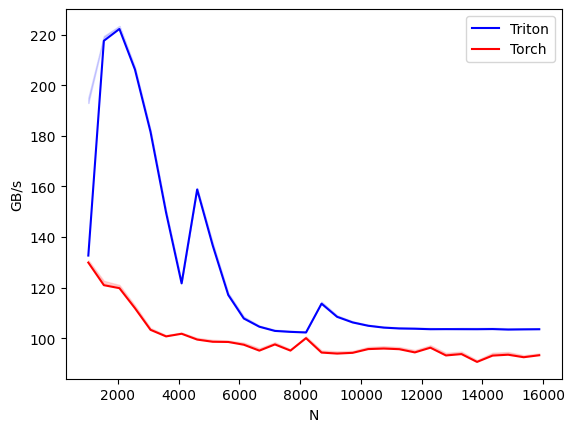

layer-norm-backward:
          N      Triton       Torch
0    1024.0  132.667325  129.902874
1    1536.0  217.548896  120.964723
2    2048.0  222.218710  119.782499
3    2560.0  206.174497  111.862268
4    3072.0  181.554136  103.321102
5    3584.0  149.658923  100.721313
6    4096.0  121.669015  101.763973
7    4608.0  158.789609   99.466930
8    5120.0  136.662403   98.599799
9    5632.0  117.093833   98.518953
10   6144.0  107.800307   97.428160
11   6656.0  104.544503   95.098804
12   7168.0  102.889373   97.546706
13   7680.0  102.513907   95.108590
14   8192.0  102.274654  100.024737
15   8704.0  113.653970   94.329404
16   9216.0  108.456347   93.934731
17   9728.0  106.238094   94.225698
18  10240.0  104.923635   95.708272
19  10752.0  104.193408   95.918596
20  11264.0  103.854305   95.666856
21  11776.0  103.758066   94.396794
22  12288.0  103.561584   96.259487
23  12800.0  103.592010   93.193057
24  13312.0  103.574129   93.731308
25  13824.0  103.559148   90.636026
26  143

In [7]:
benchmark.run(print_data=True, show_plots=True)

# Scratch